# Leading Philly students through a safe path
As part of Vision Zero, Philly's initiative to reduce traffic deaths to zero by 2030, the City is implementing is Safe Routes program to make the commute to school safer for kids. However, traffic is not the only threat that Philly students face while going to and leaving school. Gun violence is also a possible threat to students, though some students are in more risk than others.

To truly understand what a "Safe Path" to school looks like, we have to look at the data. Using public records from OpenDataPhilly, this analysis overlays two critical datasets:

1. Philadelphia Shooting Victims (2015–Present)

2. School Parcel Locations

By filtering for the specific hours when students are most active on the streets, we aim to visualize the geographic reality of student safety.

In [32]:
#Set up
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

In [16]:
# Load Data
shoot_df = pd.read_csv('data/shootings.csv') 
schools_gdf = gpd.read_file('data/Schools_Parcels.geojson')
philly_gdf = gpd.read_file('data/philadelphia_zip_boundaries.geojson')

Students are not around schools during all hours of the day. To make this analysis relevant to the student experience, we isolated incidents that occurred during School Commute Windows:

- Morning Window: 6:00 AM – 9:00 AM
- Afternoon Window: 2:30 PM – 4:30 PM
- Weekdays only (Monday through Friday).

Furthermore, we defined a 500-foot buffer around every school parcel in the city to identify incidents occurring in the immediate vicinity of our classrooms.

In [3]:
# 1. Extract the hour of the incident
shoot_df['hour_int'] = pd.to_datetime(shoot_df['time'], format='%H:%M:%S').dt.hour

# 2. Filter commute hours
is_commute_time = (
    (shoot_df['hour_int'].between(6, 8)) | 
    (shoot_df['hour_int'].between(14, 16))
)
#3. Filter commute days
shoot_df['is_weekday'] = pd.to_datetime(shoot_df['date_']).dt.dayofweek < 5

#4. Apply filters
safe_path_df = shoot_df[is_commute_time & shoot_df['is_weekday']].copy()

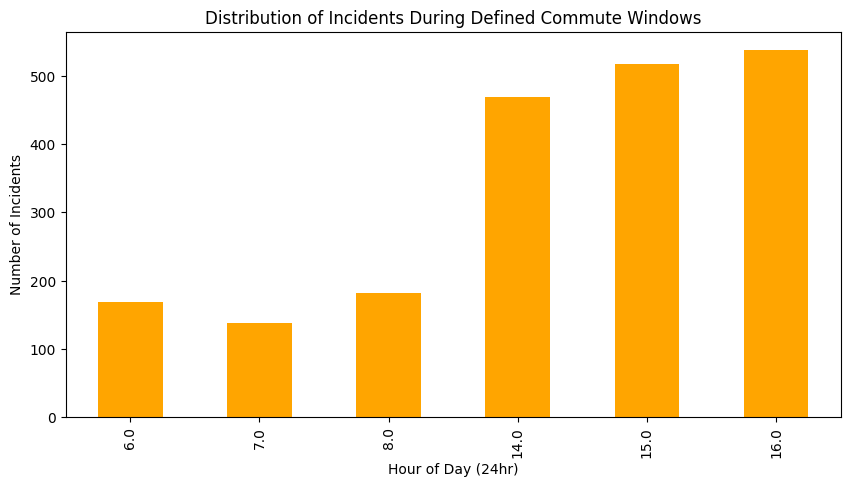

In [11]:
plt.figure(figsize=(10, 5))
safe_path_df['hour_int'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Distribution of Incidents During Defined Commute Windows')
plt.xlabel('Hour of Day (24hr)')
plt.ylabel('Number of Incidents')
plt.show()

In [23]:
# 1. Convert filtered shootings to a GeoDataFrame
shootings_gdf = gpd.GeoDataFrame(
    shoot_df, 
    geometry=gpd.points_from_xy(shoot_df.lng, shoot_df.lat), 
    crs="EPSG:4326"
)

# 2. Project both to Philly's local system (Feet)
shootings_gdf = shootings_gdf.to_crs(epsg=2272)
schools_gdf = schools_gdf.to_crs(epsg=2272)
philly_gdf = philly_gdf.to_crs(epsg=2272)

# 3. Create a 500ft Buffer around School Parcels
schools_gdf['buffer_geometry'] = schools_gdf.geometry.buffer(500)

# 4. Perform the Spatial Join
safe_path_incidents = gpd.sjoin(
    shootings_gdf, 
    schools_gdf.set_geometry('buffer_geometry'), 
    how='inner', 
    predicate='intersects'
)

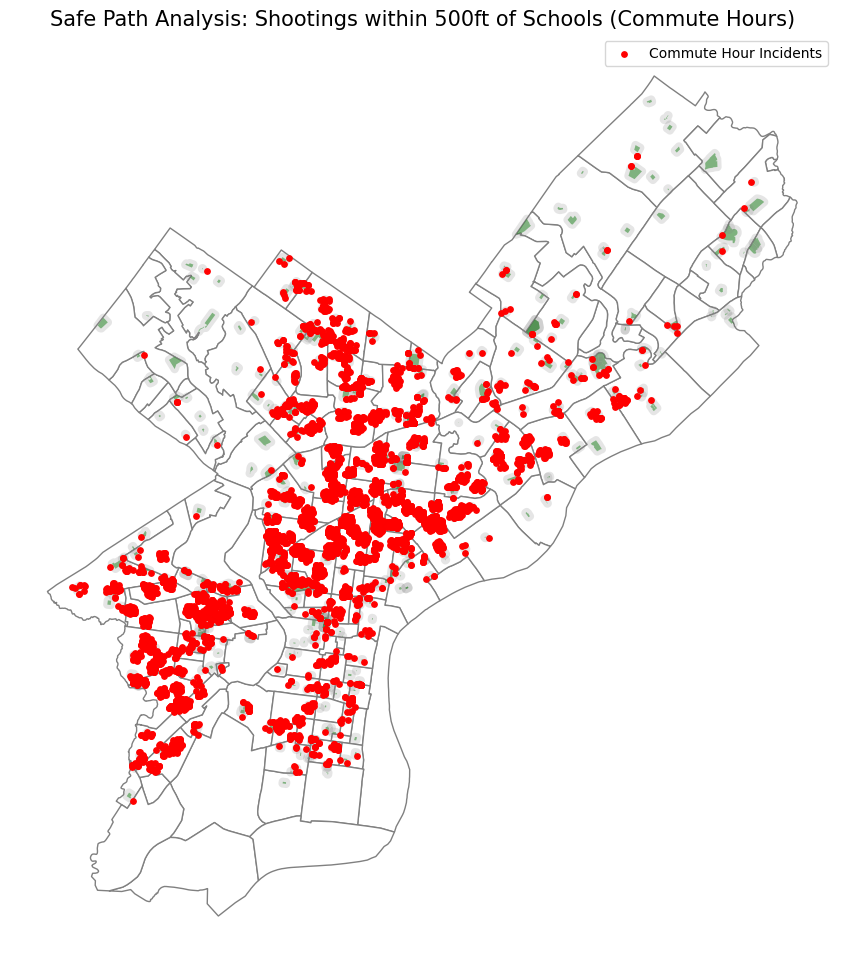

In [25]:
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the base layer (Philly boundaries)
philly_gdf.plot(ax=ax, color='white', edgecolor='gray', linewidth=1)

# Plot all school parcels in green
schools_gdf.plot(ax=ax, color='green', alpha=0.5, label='School Parcels')

# Plot the 500ft buffers in light grey
schools_gdf.set_geometry('buffer_geometry').plot(ax=ax, color='grey', alpha=0.2)

# Plot the specific incidents in red
safe_path_incidents.plot(ax=ax, color='red', markersize=15, label='Commute Hour Incidents', zorder=5)

# Labeling
ax.set_title("Safe Path Analysis: Shootings within 500ft of Schools (Commute Hours)", fontsize=15)
ax.axis('off')
plt.legend(loc='upper right')

plt.show()

The visualization above tells a stark story. While gun violence is a city-wide challenge, the burden on students is heavily concentrated. We see dense clusters in North and West Philadelphia, where school parcels (shown in green) are frequently intersected by commute-hour incidents (shown in red).

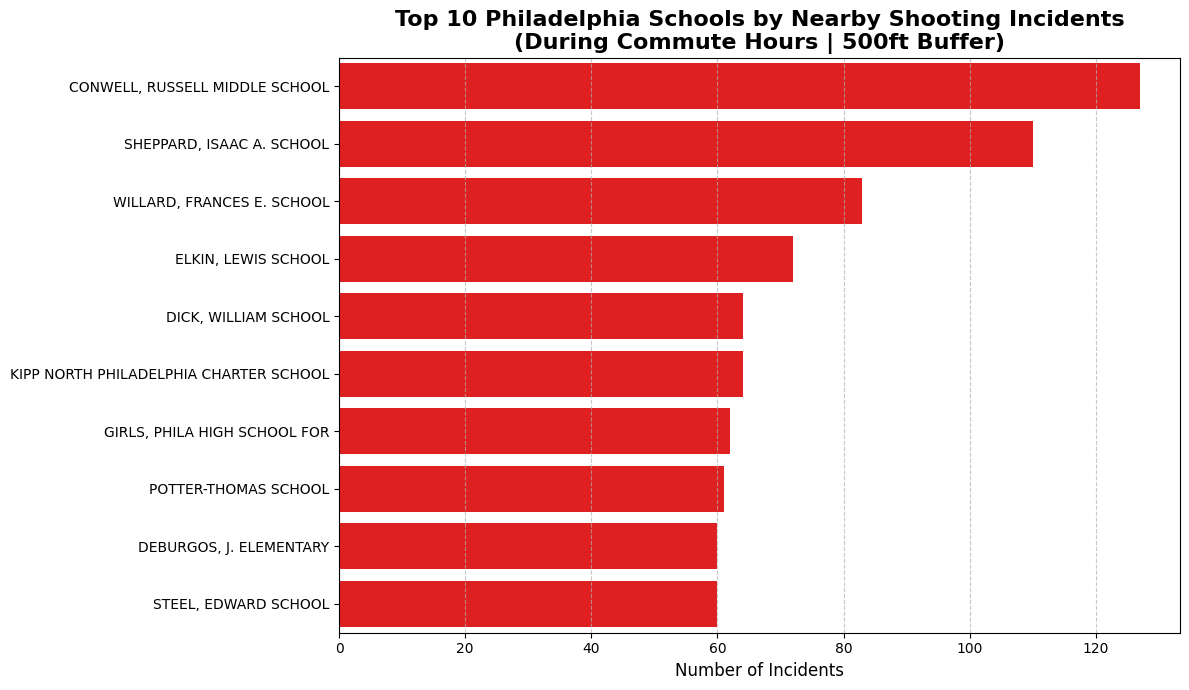

In [35]:
# 1. Identify the Top 10 Schools with the most incidents in their 500ft buffer
top_10_schools = safe_path_incidents['school_name'].value_counts().head(10).reset_index()
top_10_schools.columns = ['School Name', 'Incident Count']

# 2. Plotting the results
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_10_schools, 
    y='School Name', 
    x='Incident Count',
    color = 'red'
)

# 3. Customizing the chart for the blog post
plt.title('Top 10 Philadelphia Schools by Nearby Shooting Incidents\n(During Commute Hours | 500ft Buffer)', fontsize=16, weight='bold')
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ensure the labels are fully visible
plt.tight_layout()
plt.show()

Data allows us to move from general concern to targeted action. By quantifying the incidents within each school's 500ft buffer, we can identify the specific campuses where safety initiatives like [Safe Path monitors](https://www.penninjuryscience.org/outreach/community-violence-intervention-hub/safe-path-to-school-program/) and community corridors are most urgently needed.

As shown in the chart, the top 10 schools face a disproportionate number of nearby incidents. These numbers represent more than just data points; they represent moments where a student's safe path was compromised.

Nevertheless, it is important to understand that the data presented here is created by a diverse system of structures that create the issue of gun violence. While this data might not be the answer to the problem as a whole, it might be useful to help us protect a vulnerable population: students.